# TDGL Local Simulation

Build device mesh via K8s workflow, generate timing schedule, run TDGL solver locally.
Je is the applied current between the two electrodes (source/drain).

In [1]:
import os
import json
import uuid
import time
import tarfile
import io
import pickle

import httpx
import boto3
import numpy as np
import plotly.graph_objects as go
import tdgl
from hera.workflows import Workflow, WorkflowsService, Parameter
from hera.workflows.models import WorkflowTemplateRef as WTR
from tdgl_workflow.timing import build_timing_segmented

## Connections

In [2]:
gateway = 'http://localhost:30080'

argo_svc = WorkflowsService(
    host=gateway,
    verify_ssl=False,
    namespace='tdgl',
)

minio = boto3.client(
    's3',
    endpoint_url='http://localhost:30900',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin123',
    region_name='us-east-1',
)

print(f'Gateway: {gateway}')
print(f'MinIO Console: {gateway}/minio-ui/')

Gateway: http://localhost:30080
MinIO Console: http://localhost:30080/minio-ui/

## Device Parameters

In [3]:
params = {
    'film_width': 8.0,
    'film_height': 2.0,
    'elec_width': 0.1,
    'elec_height': 2.1,
    'elec_y_offset': 0.0,
    'probe_points': [
        [1.0, 0.0],
        [-1.0, 0.0],
    ],
    'max_edge_length': 0.25,
    'smooth': 100,
}

## Build Device (K8s)

In [4]:
run_id = str(uuid.uuid4())

wf = Workflow(
    generate_name='rect-device-',
    namespace='tdgl',
    workflow_template_ref=WTR(name='rectangle-device-builder'),
    arguments=[
        Parameter(name='run-id', value=run_id),
        Parameter(name='device-params-json', value=json.dumps(params)),
    ],
    workflows_service=argo_svc,
)

created = wf.create()
wf_name = created.metadata.name
print(f'Submitted: {wf_name}')
print(f'Run ID:    {run_id}')

Submitted: rect-device-24ftl
Run ID:    62a9f1db-93a0-4175-aa90-6e4014ebbd1f

In [5]:
hint_map = {
    'Submitted': 'Scheduling...',
    'Pending': 'Pulling image...',
    'Running': 'Computing mesh...',
}

while True:
    url = f'{argo_svc.host}/api/v1/workflows/tdgl/{wf_name}'
    resp = httpx.get(url, verify=False, timeout=10)
    resp.raise_for_status()
    phase = (resp.json().get('status') or {}).get('phase', 'Unknown')

    if phase == 'Succeeded':
        print(f'{wf_name} succeeded.')
        break
    elif phase in {'Failed', 'Error'}:
        raise RuntimeError(f'{wf_name} {phase}')
    else:
        hint = hint_map.get(phase, 'Processing...')
        print(f'{wf_name} [{phase}] {hint}')
        time.sleep(3)

# Load pickled tdgl.Device from K8s artifact
device_key = f'{run_id}/device.pkl'
resp = minio.get_object(Bucket='argo-artifacts', Key=device_key)
raw = resp['Body'].read()

with tarfile.open(fileobj=io.BytesIO(raw), mode='r:gz') as tar:
    for member in tar.getmembers():
        f = tar.extractfile(member)
        if f:
            device = pickle.load(f)
            break

points = np.asarray(device.points)
triangles = np.asarray(device.triangles)

probe_indices = []
for px, py in params['probe_points']:
    dists = np.sqrt((points[:, 0] - px) ** 2 + (points[:, 1] - py) ** 2)
    probe_indices.append(int(np.argmin(dists)))

print(f'Device: {len(points)} sites, {len(triangles)} elements')
print(f'Probes: {probe_indices}')

rect-device-24ftl [Unknown] Processing...rect-device-24ftl [Running] Computing mesh...rect-device-24ftl [Running] Computing mesh...rect-device-24ftl [Running] Computing mesh...rect-device-24ftl [Running] Computing mesh...rect-device-24ftl [Running] Computing mesh...rect-device-24ftl [Running] Computing mesh...rect-device-24ftl succeeded.
Device: 860 sites, 1608 elements
Probes: [621, 844]

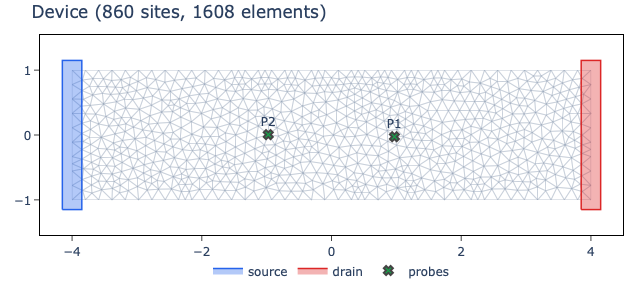

In [6]:
# Plot mesh
mx, my = [], []
for tri in triangles:
    for j in range(3):
        p0, p1 = points[tri[j]], points[tri[(j + 1) % 3]]
        mx += [p0[0], p1[0], None]
        my += [p0[1], p1[1], None]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=mx, y=my, mode='lines',
    line=dict(width=0.3, color='#94a3b8'),
    hoverinfo='skip', showlegend=False,
))

ec = {
    'source': ('#2563eb', 'rgba(37,99,235,0.35)'),
    'drain': ('#dc2626', 'rgba(220,38,38,0.35)'),
}
for t in device.terminal_info():
    idx = t.site_indices
    x0, x1 = points[idx, 0].min(), points[idx, 0].max()
    y0, y1 = points[idx, 1].min(), points[idx, 1].max()
    pad = 0.15
    lc, fc = ec.get(t.name, ('#888', 'rgba(136,136,136,0.35)'))
    fig.add_trace(go.Scatter(
        x=[x0 - pad, x1 + pad, x1 + pad, x0 - pad, x0 - pad],
        y=[y0 - pad, y0 - pad, y1 + pad, y1 + pad, y0 - pad],
        mode='lines', line=dict(width=1.5, color=lc), name=t.name,
        fill='toself', fillcolor=fc,
    ))

fig.add_trace(go.Scatter(
    x=points[probe_indices, 0], y=points[probe_indices, 1],
    mode='markers+text',
    marker=dict(size=8, symbol='x', color='#16a34a', line_width=2),
    text=[f'P{i+1}' for i in range(len(probe_indices))],
    textposition='top center', name='probes',
))

xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()
m = 0.3
fig.update_layout(
    title=f'Device ({len(points)} sites, {len(triangles)} elements)',
    xaxis=dict(range=[xmin - m, xmax + m], showline=True, linewidth=1,
               linecolor='black', mirror=True, ticks='outside'),
    yaxis=dict(scaleanchor='x', scaleratio=1, range=[ymin - m, ymax + m],
               showline=True, linewidth=1, linecolor='black', mirror=True, ticks='outside'),
    legend=dict(orientation='h', yanchor='bottom', y=-0.25, xanchor='center', x=0.5),
    margin=dict(l=40, r=10, t=35, b=50),
    height=280, width=700, plot_bgcolor='white',
)
fig.show()

## Timing Parameters

In [7]:
# Base timing parameters
je_initial = 0.0
je_final = 10.5
je_step = 0.1
ramp_time = 50.0
stable_time = 50.0
save_time = 20.0

segments = [
    {'je_initial': je_initial, 'je_final': je_final, 'je_step': je_step},
    {'je_initial': je_final, 'je_final': je_initial, 'je_step': -je_step},
]

In [8]:
result = build_timing_segmented(
    segments=segments,
    ramp_time=ramp_time,
    stable_time=stable_time,
    save_time=save_time,
)

steps = result['steps']
eq = steps[0]
print(f"Total steps: {result['n_steps']} (1 eq + {result['n_steps'] - 1} ramp)")
print(f"Solve time:  {result['solve_time']:.1f}s")
print()
print(f"  eq:  hold je={eq['je_start']:.2f}  t=0.0..{eq['stable_end']:.1f}s")
for i, s in enumerate(steps[1:], 1):
    print(f"  {i:2d}: je {s['je_start']:.2f} -> {s['je_end']:.2f}  "
          f"t={s['ramp_start']:.1f}..{s['stable_end']:.1f}s")

Total steps: 211 (1 eq + 210 ramp)
Solve time:  21050.0s

  eq:  hold je=0.00  t=0.0..50.0s
   1: je 0.00 -> 0.10  t=50.0..150.0s
   2: je 0.10 -> 0.20  t=150.0..250.0s
   3: je 0.20 -> 0.30  t=250.0..350.0s
   4: je 0.30 -> 0.40  t=350.0..450.0s
   5: je 0.40 -> 0.50  t=450.0..550.0s
   6: je 0.50 -> 0.60  t=550.0..650.0s
   7: je 0.60 -> 0.70  t=650.0..750.0s
   8: je 0.70 -> 0.80  t=750.0..850.0s
   9: je 0.80 -> 0.90  t=850.0..950.0s
  10: je 0.90 -> 1.00  t=950.0..1050.0s
  11: je 1.00 -> 1.10  t=1050.0..1150.0s
  12: je 1.10 -> 1.20  t=1150.0..1250.0s
  13: je 1.20 -> 1.30  t=1250.0..1350.0s
  14: je 1.30 -> 1.40  t=1350.0..1450.0s
  15: je 1.40 -> 1.50  t=1450.0..1550.0s
  16: je 1.50 -> 1.60  t=1550.0..1650.0s
  17: je 1.60 -> 1.70  t=1650.0..1750.0s
  18: je 1.70 -> 1.80  t=1750.0..1850.0s
  19: je 1.80 -> 1.90  t=1850.0..1950.0s
  20: je 1.90 -> 2.00  t=1950.0..2050.0s
  21: je 2.00 -> 2.10  t=2050.0..2150.0s
  22: je 2.10 -> 2.20  t=2150.0..2250.0s
  23: je 2.20 -> 2.30  t=2

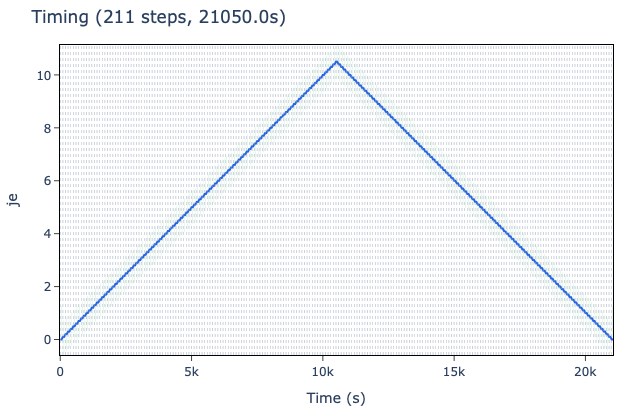

In [9]:
# Plot timing schedule
times = []
je_vals = []
for s in steps:
    times += [s['ramp_start'], s['ramp_end'], s['stable_end']]
    je_vals += [s['je_start'], s['je_end'], s['je_end']]

je_max = max(s['je_end'] for s in steps) or 1.0
band = je_max * 0.06

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=times, y=je_vals, mode='lines',
    line=dict(width=2, color='#2563eb'),
    name='Applied je',
))

for s in steps:
    y_center = s['je_end'] if s['je_end'] != 0 else band
    fig.add_shape(
        type='rect',
        x0=s['save_start'], x1=s['save_end'],
        y0=y_center - band, y1=y_center + band,
        fillcolor='rgba(22,163,74,0.18)', line_width=0,
    )

for s in steps:
    fig.add_vline(x=s['ramp_end'], line_width=0.5,
                  line_dash='dot', line_color='#94a3b8')

fig.update_layout(
    title=f"Timing ({len(steps)} steps, {result['solve_time']:.1f}s)",
    xaxis_title='Time (s)',
    yaxis_title='je',
    legend=dict(orientation='h', yanchor='bottom', y=1.02,
                xanchor='right', x=1),
    margin=dict(l=60, r=20, t=45, b=50),
    height=400, width=800, plot_bgcolor='white',
    xaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
    yaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
)
fig.show()

## Run Simulation

In [10]:
# Solver parameters
dt_init = 1e-6
dt_max = 0.1
adaptive = True
save_every = 100
output_path = 'sim_output.h5'

In [11]:
# Build terminal currents callable from timing steps
def get_terminal_currents(t):
    """Return {terminal_name: current} at time t."""
    for step in steps:
        if t < step['ramp_start']:
            continue
        ramp_duration = step['ramp_end'] - step['ramp_start']
        if ramp_duration > 0 and t <= step['ramp_end']:
            frac = (t - step['ramp_start']) / ramp_duration
            je = step['je_start'] + frac * (step['je_end'] - step['je_start'])
            return {'source': je, 'drain': -je}
        if t <= step['stable_end']:
            return {'source': step['je_end'], 'drain': -step['je_end']}
    return {'source': 0.0, 'drain': 0.0}


# Clean up previous output
if os.path.exists(output_path):
    os.remove(output_path)

options = tdgl.SolverOptions(
    solve_time=result['solve_time'],
    dt_init=dt_init,
    dt_max=dt_max,
    adaptive=adaptive,
    save_every=save_every,
    output_file=output_path,
)

solution = tdgl.solve(
    device,
    options,
    terminal_currents=get_terminal_currents,
)

print(f'Simulation complete. Saved {len(solution.times)} frames to {output_path}')

Simulating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 21050/21050.0 [01:03<00:00, 329.64tau/s ]

Simulation complete. Saved 3376 frames to sim_output.h5

## Results

In [12]:
from tdgl.solution.data import DynamicsData

dynamics = DynamicsData.from_solution(solution.path, progress_bar=True)
sol_times = np.asarray(solution.times, dtype=np.float64)

iv_je = []
iv_voltage = []

for step in steps:
    mask = (sol_times >= step['save_start']) & (sol_times <= step['save_end'])
    indices = np.where(mask)[0]
    if len(indices) == 0:
        continue
    voltages = dynamics.mu[1, indices] - dynamics.mu[0, indices]
    iv_je.append(step['je_end'])
    iv_voltage.append(float(np.mean(voltages)))

print(f'Extracted {len(iv_je)} I-V points')
for je, v in zip(iv_je, iv_voltage):
    print(f'  je={je:6.2f}  V={v:+.6f}')

Time steps: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3376/3376 [00:04<00:00, 765.61it/s]

Extracted 211 I-V points
  je=  0.00  V=+0.000000
  je=  0.10  V=+0.000000
  je=  0.20  V=+0.000000
  je=  0.30  V=+0.000000
  je=  0.40  V=+0.000001
  je=  0.50  V=+0.000001
  je=  0.60  V=+0.000001
  je=  0.70  V=+0.000001
  je=  0.80  V=+0.000001
  je=  0.90  V=+0.000001
  je=  1.00  V=+0.000002
  je=  1.10  V=+0.000002
  je=  1.20  V=+0.000002
  je=  1.30  V=+0.000002
  je=  1.40  V=+0.000002
  je=  1.50  V=+0.000002
  je=  1.60  V=+0.000003
  je=  1.70  V=+0.000003
  je=  1.80  V=+0.000003
  je=  1.90  V=+0.000003
  je=  2.00  V=+0.000003
  je=  2.10  V=+0.000004
  je=  2.20  V=+0.000004
  je=  2.30  V=+0.000004
  je=  2.40  V=+0.000004
  je=  2.50  V=+0.000004
  je=  2.60  V=+0.000005
  je=  2.70  V=+0.000005
  je=  2.80  V=+0.000005
  je=  2.90  V=+0.000005
  je=  3.00  V=+0.000005
  je=  3.10  V=+0.000005
  je=  3.20  V=+0.000006
  je=  3.30  V=+0.000006
  je=  3.40  V=+0.000006
  je=  3.50  V=+0.000006
  je=  3.60  V=+0.000007
  je=  3.70  V=+0.000007
  je=  3.80  V=+0.000007


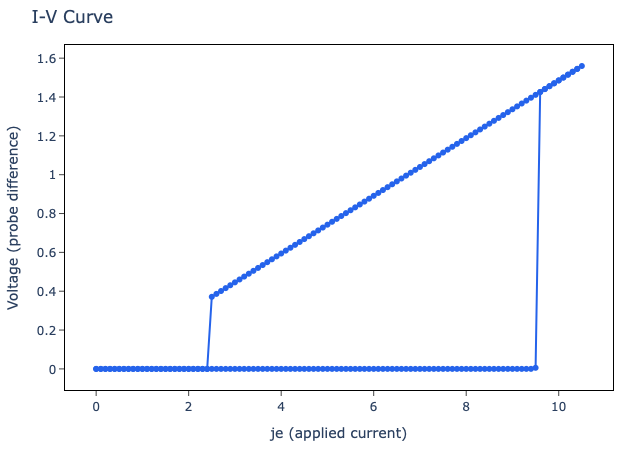

In [13]:
# Plot I-V curve
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=iv_je, y=iv_voltage, mode='lines+markers',
    line=dict(width=2, color='#2563eb'),
    marker=dict(size=6),
    name='I-V',
))
fig.update_layout(
    title='I-V Curve',
    xaxis_title='je (applied current)',
    yaxis_title='Voltage (probe difference)',
    margin=dict(l=60, r=20, t=45, b=50),
    height=450, width=600, plot_bgcolor='white',
    xaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
    yaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
)
fig.show()

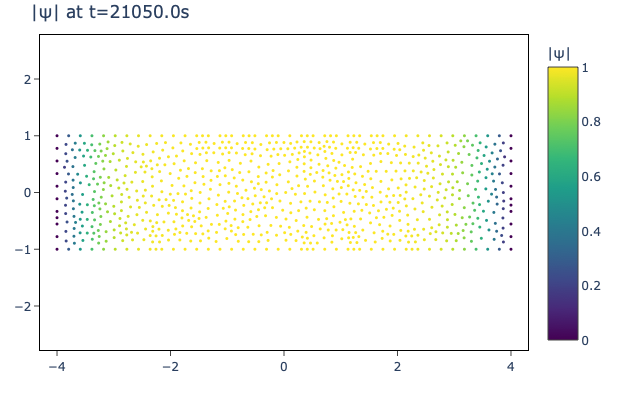

In [14]:
# Plot |psi| at the last saved frame
last_idx = len(sol_times) - 1
solution.load_tdgl_data(last_idx)
psi = solution.tdgl_data.psi
psi_abs = np.abs(psi)

fig = go.Figure(go.Scatter(
    x=points[:, 0], y=points[:, 1],
    mode='markers',
    marker=dict(
        size=3,
        color=psi_abs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='|\u03C8|'),
    ),
    text=[f'|\u03C8|={v:.3f}' for v in psi_abs],
    hovertemplate='%{text}<extra></extra>',
))

xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()
m = 0.3
fig.update_layout(
    title=f'|\u03C8| at t={sol_times[last_idx]:.1f}s',
    xaxis=dict(range=[xmin - m, xmax + m], showline=True, linewidth=1,
               linecolor='black', mirror=True, ticks='outside'),
    yaxis=dict(scaleanchor='x', scaleratio=1, range=[ymin - m, ymax + m],
               showline=True, linewidth=1, linecolor='black', mirror=True, ticks='outside'),
    margin=dict(l=40, r=10, t=35, b=50),
    height=400, width=700, plot_bgcolor='white',
)
fig.show()

## Heatmap Animation

Interactive Plotly viewer with play/pause/seek controls.
One frame per timing step, computed on-demand from HDF5.
Works with completed simulation or live background solver (cell 22).


In [15]:
# Launch solver in background thread
import threading

if os.path.exists(output_path):
    os.remove(output_path)

options = tdgl.SolverOptions(
    solve_time=result['solve_time'],
    dt_init=dt_init,
    dt_max=dt_max,
    adaptive=adaptive,
    save_every=save_every,
    output_file=output_path,
)

sim_done = threading.Event()

def run_sim():
    global solution
    solution = tdgl.solve(
        device, options,
        terminal_currents=get_terminal_currents,
    )
    print(f'\nSimulation complete. {len(solution.times)} frames saved.')
    sim_done.set()

thread = threading.Thread(target=run_sim, daemon=True)
thread.start()
print('Solver running in background. Run the next cell to start the live viewer.')

Solver running in background. Run the next cell to start the live viewer.

In [16]:
import ipywidgets as widgets
import h5py
from scipy.interpolate import griddata

# Check sim_done event (set by cell 22 background solver)
try:
    _ = sim_done
except NameError:
    sim_done = threading.Event()
    sim_done.set()

# Interpolation grid
xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()
nx, ny = 100, 50
gx = np.linspace(xmin, xmax, nx)
gy = np.linspace(ymin, ymax, ny)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])

# Read frame times from HDF5
def read_frame_times():
    if not os.path.exists(output_path):
        return np.array([])
    try:
        with h5py.File(output_path, 'r') as f:
            if 'data' not in f:
                return np.array([])
            total = len(f['data'].keys())
            if total == 0:
                return np.array([])
            return np.array([
                float(f[f'data/{fi}'].attrs.get('time', 0))
                for fi in range(total)
            ])
    except Exception:
        return np.array([])

# Compute heatmap for a given step index
def compute_frame(step_idx):
    """Compute interpolated |psi| heatmap for timing step step_idx (0-based)."""
    s = steps[step_idx]
    frame_times = read_frame_times()
    if len(frame_times) == 0:
        return np.zeros((ny, nx)), {'je': s['je_end'], 'step': step_idx + 1, 'time': 0}

    mid_t = (s['save_start'] + s['save_end']) / 2
    mask = (frame_times >= s['save_start']) & (frame_times <= s['save_end'])
    step_fi = np.where(mask)[0]

    if len(step_fi) > 0:
        fi = step_fi[len(step_fi) // 2]
    else:
        fi = int(np.argmin(np.abs(frame_times - mid_t)))

    with h5py.File(output_path, 'r') as f:
        psi = np.abs(np.array(f[f'data/{fi}/psi']))

    Z = griddata(points, psi, grid_pts, method='cubic',
                 fill_value=0.0).reshape(ny, nx)
    Z = np.clip(Z, 0, None)
    info = {'je': s['je_end'], 'step': step_idx + 1,
            'time': (s['save_start'] + s['save_end']) / 2}
    return Z, info

n_steps = len(steps)

# Initial frame
initial_Z, initial_info = compute_frame(0)

# Electrode rectangles as shapes
electrode_shapes = []
for t in device.terminal_info():
    idx = t.site_indices
    x0, x1 = points[idx, 0].min(), points[idx, 0].max()
    y0, y1 = points[idx, 1].min(), points[idx, 1].max()
    electrode_shapes.append(dict(
        type='rect', x0=x0, x1=x1, y0=y0, y1=y1,
        line=dict(color='cyan', width=1.5, dash='dash'),
        fillcolor='rgba(0,0,0,0)', layer='above',
    ))

# Build Plotly FigureWidget
fig = go.FigureWidget(
    go.Heatmap(x=gx, y=gy, z=initial_Z,
               colorscale='Inferno', zmin=0, zmax=1.05,
               colorbar=dict(title='|ψ|'),
               showscale=True),
)
fig.update_layout(
    title=f'|ψ|  je={initial_info["je"]:.2f}  t={initial_info["time"]:.0f}s  '
          f'(step 1/{n_steps})',
    xaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
    yaxis=dict(scaleanchor='x', scaleratio=1, showline=True,
               linewidth=1, linecolor='black', mirror=True, ticks='outside'),
    margin=dict(l=50, r=10, t=35, b=50),
    height=400, width=700, plot_bgcolor='white',
    shapes=electrode_shapes,
)

# Play + Slider controls
slider = widgets.IntSlider(
    value=0, min=0, max=n_steps - 1, step=1,
    description='Step:', continuous_update=True,
)
play = widgets.Play(
    value=0, min=0, max=n_steps - 1, interval=80,
    description='Play',
)
widgets.jslink((play, 'value'), (slider, 'value'))

# Frame update callback
def on_slider_change(change):
    idx = change['new']
    Z, info = compute_frame(idx)
    fig.data[0].z = Z
    fig.update_layout(
        title=f'|ψ|  je={info["je"]:.2f}  t={info["time"]:.0f}s  '
              f'(step {info["step"]}/{n_steps})')

slider.observe(on_slider_change, names='value')

# Poller: update slider max during live simulation
def poll_progress():
    if sim_done.is_set():
        return
    frame_times = read_frame_times()
    if len(frame_times) > 0:
        completed = 0
        for s in steps:
            if np.any((frame_times >= s['save_start']) & (frame_times <= s['save_end'])):
                completed += 1
            else:
                break
        if completed > 0:
            slider.max = completed - 1
            play.max = completed - 1
    threading.Timer(2.0, poll_progress).start()

if not sim_done.is_set():
    poll_progress()

# Display
controls = widgets.HBox([play, slider])
display(widgets.VBox([controls, fig]))
print(f'{n_steps} timing steps — use Play/Slider to browse frames')


Background simulation still running. Waiting for it to finish...

Simulating: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 21050/21050.0 [01:02<00:00, 334.89tau/s ]


Simulation complete. 3376 frames saved.
Simulation complete.211 frames (211 with data) — je 0.00 → 10.50 → 0.00

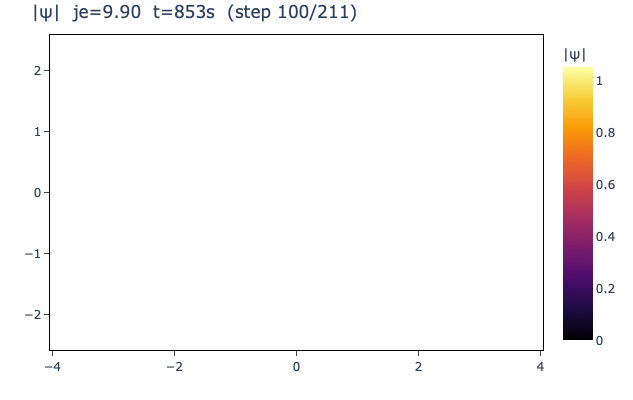

In [103]:
# View a single frame by timing step index (1-based)
step_idx = 100  # change this (1..211)

if step_idx < 1 or step_idx > len(steps):
    print(f'Step must be 1..{len(steps)}')
else:
    Z, info = compute_frame(step_idx - 1)
    fig_single = go.Figure(go.Heatmap(
        x=gx, y=gy, z=Z, colorscale='Inferno',
        zmin=0, zmax=1.05, showscale=True,
        colorbar=dict(title='|ψ|'),
    ))
    fig_single.update_layout(
        title=f'|ψ|  je={info["je"]:.2f}  t={info["time"]:.0f}s  '
              f'(step {info["step"]}/{len(steps)})',
        xaxis=dict(showline=True, linewidth=1, linecolor='black',
                   mirror=True, ticks='outside'),
        yaxis=dict(scaleanchor='x', scaleratio=1, showline=True,
                   linewidth=1, linecolor='black', mirror=True, ticks='outside'),
        margin=dict(l=50, r=10, t=35, b=50),
        height=400, width=700, plot_bgcolor='white',
        shapes=electrode_shapes,
    )
    fig_single.show()


## MinIO Artifact Management

In [ ]:
# Delete current run's artifact
minio.delete_object(Bucket='argo-artifacts', Key=device_key)
print(f'Deleted {device_key}')

In [ ]:
# List all artifacts
resp = minio.list_objects_v2(Bucket='argo-artifacts')
items = resp.get('Contents', [])

if not items:
    print('No artifacts in bucket.')
else:
    print(f'Found {len(items)} artifact(s):\n')
    for obj in items:
        print(f'  {obj["Key"]}  ({obj["Size"]/1024:.1f} KB)')

In [ ]:
# Delete a specific artifact — change the key below
delete_key = '<run-id>/device.pkl'

minio.delete_object(Bucket='argo-artifacts', Key=delete_key)
print(f'Deleted {delete_key}')

In [ ]:
# Delete ALL device artifacts
resp = minio.list_objects_v2(Bucket='argo-artifacts')
count = 0
for obj in resp.get('Contents', []):
    if 'device.pkl' in obj['Key']:
        minio.delete_object(Bucket='argo-artifacts', Key=obj['Key'])
        print(f'Deleted {obj["Key"]}')
        count += 1
print(f'\nDone. Removed {count} artifact(s).')

# TDGL Local Simulation

Build device mesh via K8s workflow, generate timing schedule, run TDGL solver locally.
Je is the applied current between the two electrodes (source/drain).

In [2]:
import os
import json
import uuid
import time
import tarfile
import io
import pickle

import httpx
import boto3
import numpy as np
import plotly.graph_objects as go
import tdgl
from hera.workflows import Workflow, WorkflowsService, Parameter
from hera.workflows.models import WorkflowTemplateRef as WTR
from tdgl_workflow.timing import build_timing_segmented

## Connections

In [3]:
gateway = 'http://localhost:30080'

argo_svc = WorkflowsService(
    host=gateway,
    verify_ssl=False,
    namespace='tdgl',
)

minio = boto3.client(
    's3',
    endpoint_url='http://localhost:30900',
    aws_access_key_id='minioadmin',
    aws_secret_access_key='minioadmin123',
    region_name='us-east-1',
)

print(f'Gateway: {gateway}')
print(f'MinIO Console: {gateway}/minio-ui/')

Gateway: http://localhost:30080
MinIO Console: http://localhost:30080/minio-ui/

## Device Parameters

In [55]:
params = {
    'film_width': 8.0,
    'film_height': 2.0,
    'elec_width': 0.1,
    'elec_height': 2.1,
    'elec_y_offset': 0.0,
    'probe_points': [
        [1.0, 0.0],
        [-1.0, 0.0],
    ],
    'max_edge_length': 0.25,
    'smooth': 100,
}

## Build Device (K8s)

In [56]:
run_id = str(uuid.uuid4())

wf = Workflow(
    generate_name='rect-device-',
    namespace='tdgl',
    workflow_template_ref=WTR(name='rectangle-device-builder'),
    arguments=[
        Parameter(name='run-id', value=run_id),
        Parameter(name='device-params-json', value=json.dumps(params)),
    ],
    workflows_service=argo_svc,
)

created = wf.create()
wf_name = created.metadata.name
print(f'Submitted: {wf_name}')
print(f'Run ID:    {run_id}')

Submitted: rect-device-tq5gw
Run ID:    0461c377-551c-4250-ba04-c28e633c526f

In [57]:
hint_map = {
    'Submitted': 'Scheduling...',
    'Pending': 'Pulling image...',
    'Running': 'Computing mesh...',
}

while True:
    url = f'{argo_svc.host}/api/v1/workflows/tdgl/{wf_name}'
    resp = httpx.get(url, verify=False, timeout=10)
    resp.raise_for_status()
    phase = (resp.json().get('status') or {}).get('phase', 'Unknown')

    if phase == 'Succeeded':
        print(f'{wf_name} succeeded.')
        break
    elif phase in {'Failed', 'Error'}:
        raise RuntimeError(f'{wf_name} {phase}')
    else:
        hint = hint_map.get(phase, 'Processing...')
        print(f'{wf_name} [{phase}] {hint}')
        time.sleep(3)

# Load pickled tdgl.Device from K8s artifact
device_key = f'{run_id}/device.pkl'
resp = minio.get_object(Bucket='argo-artifacts', Key=device_key)
raw = resp['Body'].read()

with tarfile.open(fileobj=io.BytesIO(raw), mode='r:gz') as tar:
    for member in tar.getmembers():
        f = tar.extractfile(member)
        if f:
            device = pickle.load(f)
            break

points = np.asarray(device.points)
triangles = np.asarray(device.triangles)

probe_indices = []
for px, py in params['probe_points']:
    dists = np.sqrt((points[:, 0] - px) ** 2 + (points[:, 1] - py) ** 2)
    probe_indices.append(int(np.argmin(dists)))

print(f'Device: {len(points)} sites, {len(triangles)} elements')
print(f'Probes: {probe_indices}')

rect-device-tq5gw [Running] Computing mesh...rect-device-tq5gw [Running] Computing mesh...rect-device-tq5gw [Running] Computing mesh...rect-device-tq5gw [Running] Computing mesh...rect-device-tq5gw [Running] Computing mesh...rect-device-tq5gw [Running] Computing mesh...rect-device-tq5gw [Running] Computing mesh...rect-device-tq5gw succeeded.
Device: 860 sites, 1608 elements
Probes: [621, 844]

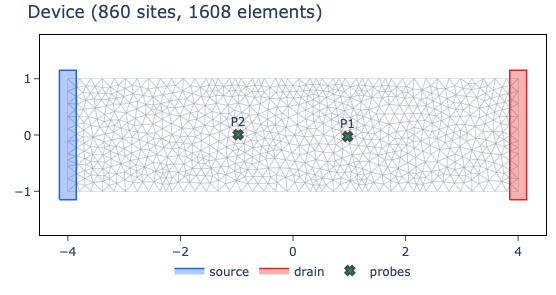

In [59]:
# Plot mesh
mx, my = [], []
for tri in triangles:
    for j in range(3):
        p0, p1 = points[tri[j]], points[tri[(j + 1) % 3]]
        mx += [p0[0], p1[0], None]
        my += [p0[1], p1[1], None]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=mx, y=my, mode='lines',
    line=dict(width=0.3, color='#94a3b8'),
    hoverinfo='skip', showlegend=False,
))

ec = {
    'source': ('#2563eb', 'rgba(37,99,235,0.35)'),
    'drain': ('#dc2626', 'rgba(220,38,38,0.35)'),
}
for t in device.terminal_info():
    idx = t.site_indices
    x0, x1 = points[idx, 0].min(), points[idx, 0].max()
    y0, y1 = points[idx, 1].min(), points[idx, 1].max()
    pad = 0.15
    lc, fc = ec.get(t.name, ('#888', 'rgba(136,136,136,0.35)'))
    fig.add_trace(go.Scatter(
        x=[x0 - pad, x1 + pad, x1 + pad, x0 - pad, x0 - pad],
        y=[y0 - pad, y0 - pad, y1 + pad, y1 + pad, y0 - pad],
        mode='lines', line=dict(width=1.5, color=lc), name=t.name,
        fill='toself', fillcolor=fc,
    ))

fig.add_trace(go.Scatter(
    x=points[probe_indices, 0], y=points[probe_indices, 1],
    mode='markers+text',
    marker=dict(size=8, symbol='x', color='#16a34a', line_width=2),
    text=[f'P{i+1}' for i in range(len(probe_indices))],
    textposition='top center', name='probes',
))

xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()
m = 0.3
fig.update_layout(
    title=f'Device ({len(points)} sites, {len(triangles)} elements)',
    xaxis=dict(range=[xmin - m, xmax + m], showline=True, linewidth=1,
               linecolor='black', mirror=True, ticks='outside'),
    yaxis=dict(scaleanchor='x', scaleratio=1, range=[ymin - m, ymax + m],
               showline=True, linewidth=1, linecolor='black', mirror=True, ticks='outside'),
    legend=dict(orientation='h', yanchor='bottom', y=-0.25, xanchor='center', x=0.5),
    margin=dict(l=40, r=10, t=35, b=50),
    height=280, width=700, plot_bgcolor='white',
)
fig.show()

## Timing Parameters

In [63]:
# Base timing parameters
je_initial = 0.0
je_final = 10.5
je_step = 0.1
ramp_time = 50.0
stable_time = 50.0
save_time = 20.0

segments = [
    {'je_initial': je_initial, 'je_final': je_final, 'je_step': je_step},
    {'je_initial': je_final, 'je_final': je_initial, 'je_step': -je_step},
]

In [64]:
result = build_timing_segmented(
    segments=segments,
    ramp_time=ramp_time,
    stable_time=stable_time,
    save_time=save_time,
)

steps = result['steps']
eq = steps[0]
print(f"Total steps: {result['n_steps']} (1 eq + {result['n_steps'] - 1} ramp)")
print(f"Solve time:  {result['solve_time']:.1f}s")
print()
print(f"  eq:  hold je={eq['je_start']:.2f}  t=0.0..{eq['stable_end']:.1f}s")
for i, s in enumerate(steps[1:], 1):
    print(f"  {i:2d}: je {s['je_start']:.2f} -> {s['je_end']:.2f}  "
          f"t={s['ramp_start']:.1f}..{s['stable_end']:.1f}s")

Total steps: 211 (1 eq + 210 ramp)
Solve time:  21050.0s

  eq:  hold je=0.00  t=0.0..50.0s
   1: je 0.00 -> 0.10  t=50.0..150.0s
   2: je 0.10 -> 0.20  t=150.0..250.0s
   3: je 0.20 -> 0.30  t=250.0..350.0s
   4: je 0.30 -> 0.40  t=350.0..450.0s
   5: je 0.40 -> 0.50  t=450.0..550.0s
   6: je 0.50 -> 0.60  t=550.0..650.0s
   7: je 0.60 -> 0.70  t=650.0..750.0s
   8: je 0.70 -> 0.80  t=750.0..850.0s
   9: je 0.80 -> 0.90  t=850.0..950.0s
  10: je 0.90 -> 1.00  t=950.0..1050.0s
  11: je 1.00 -> 1.10  t=1050.0..1150.0s
  12: je 1.10 -> 1.20  t=1150.0..1250.0s
  13: je 1.20 -> 1.30  t=1250.0..1350.0s
  14: je 1.30 -> 1.40  t=1350.0..1450.0s
  15: je 1.40 -> 1.50  t=1450.0..1550.0s
  16: je 1.50 -> 1.60  t=1550.0..1650.0s
  17: je 1.60 -> 1.70  t=1650.0..1750.0s
  18: je 1.70 -> 1.80  t=1750.0..1850.0s
  19: je 1.80 -> 1.90  t=1850.0..1950.0s
  20: je 1.90 -> 2.00  t=1950.0..2050.0s
  21: je 2.00 -> 2.10  t=2050.0..2150.0s
  22: je 2.10 -> 2.20  t=2150.0..2250.0s
  23: je 2.20 -> 2.30  t=2

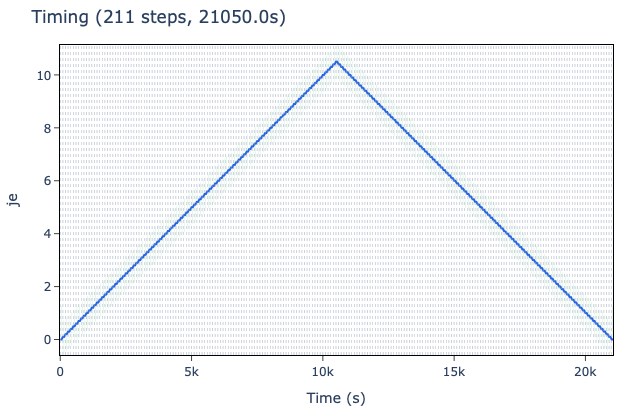

In [65]:
# Plot timing schedule
times = []
je_vals = []
for s in steps:
    times += [s['ramp_start'], s['ramp_end'], s['stable_end']]
    je_vals += [s['je_start'], s['je_end'], s['je_end']]

je_max = max(s['je_end'] for s in steps) or 1.0
band = je_max * 0.06

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=times, y=je_vals, mode='lines',
    line=dict(width=2, color='#2563eb'),
    name='Applied je',
))

for s in steps:
    y_center = s['je_end'] if s['je_end'] != 0 else band
    fig.add_shape(
        type='rect',
        x0=s['save_start'], x1=s['save_end'],
        y0=y_center - band, y1=y_center + band,
        fillcolor='rgba(22,163,74,0.18)', line_width=0,
    )

for s in steps:
    fig.add_vline(x=s['ramp_end'], line_width=0.5,
                  line_dash='dot', line_color='#94a3b8')

fig.update_layout(
    title=f"Timing ({len(steps)} steps, {result['solve_time']:.1f}s)",
    xaxis_title='Time (s)',
    yaxis_title='je',
    legend=dict(orientation='h', yanchor='bottom', y=1.02,
                xanchor='right', x=1),
    margin=dict(l=60, r=20, t=45, b=50),
    height=400, width=800, plot_bgcolor='white',
    xaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
    yaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
)
fig.show()

## Run Simulation

In [66]:
# Solver parameters
dt_init = 1e-6
dt_max = 0.1
adaptive = True
save_every = 100
output_path = 'sim_output.h5'

In [67]:
# Build terminal currents callable from timing steps
def get_terminal_currents(t):
    """Return {terminal_name: current} at time t."""
    for step in steps:
        if t < step['ramp_start']:
            continue
        ramp_duration = step['ramp_end'] - step['ramp_start']
        if ramp_duration > 0 and t <= step['ramp_end']:
            frac = (t - step['ramp_start']) / ramp_duration
            je = step['je_start'] + frac * (step['je_end'] - step['je_start'])
            return {'source': je, 'drain': -je}
        if t <= step['stable_end']:
            return {'source': step['je_end'], 'drain': -step['je_end']}
    return {'source': 0.0, 'drain': 0.0}


# Clean up previous output
if os.path.exists(output_path):
    os.remove(output_path)

options = tdgl.SolverOptions(
    solve_time=result['solve_time'],
    dt_init=dt_init,
    dt_max=dt_max,
    adaptive=adaptive,
    save_every=save_every,
    output_file=output_path,
)

solution = tdgl.solve(
    device,
    options,
    terminal_currents=get_terminal_currents,
)

print(f'Simulation complete. Saved {len(solution.times)} frames to {output_path}')

Simulating: 100%|█████████▉| 21050/21050.0 [01:14<00:00, 284.16tau/s ]

Simulation complete. Saved 3376 frames to sim_output.h5

## Results

In [68]:
from tdgl.solution.data import DynamicsData

dynamics = DynamicsData.from_solution(solution.path, progress_bar=True)
sol_times = np.asarray(solution.times, dtype=np.float64)

iv_je = []
iv_voltage = []

for step in steps:
    mask = (sol_times >= step['save_start']) & (sol_times <= step['save_end'])
    indices = np.where(mask)[0]
    if len(indices) == 0:
        continue
    voltages = dynamics.mu[1, indices] - dynamics.mu[0, indices]
    iv_je.append(step['je_end'])
    iv_voltage.append(float(np.mean(voltages)))

print(f'Extracted {len(iv_je)} I-V points')
for je, v in zip(iv_je, iv_voltage):
    print(f'  je={je:6.2f}  V={v:+.6f}')

Time steps: 100%|██████████| 3376/3376 [00:04<00:00, 799.56it/s]

Extracted 211 I-V points
  je=  0.00  V=+0.000000
  je=  0.10  V=+0.000000
  je=  0.20  V=+0.000000
  je=  0.30  V=+0.000000
  je=  0.40  V=+0.000001
  je=  0.50  V=+0.000001
  je=  0.60  V=+0.000001
  je=  0.70  V=+0.000001
  je=  0.80  V=+0.000001
  je=  0.90  V=+0.000001
  je=  1.00  V=+0.000002
  je=  1.10  V=+0.000002
  je=  1.20  V=+0.000002
  je=  1.30  V=+0.000002
  je=  1.40  V=+0.000002
  je=  1.50  V=+0.000002
  je=  1.60  V=+0.000003
  je=  1.70  V=+0.000003
  je=  1.80  V=+0.000003
  je=  1.90  V=+0.000003
  je=  2.00  V=+0.000003
  je=  2.10  V=+0.000004
  je=  2.20  V=+0.000004
  je=  2.30  V=+0.000004
  je=  2.40  V=+0.000004
  je=  2.50  V=+0.000004
  je=  2.60  V=+0.000005
  je=  2.70  V=+0.000005
  je=  2.80  V=+0.000005
  je=  2.90  V=+0.000005
  je=  3.00  V=+0.000005
  je=  3.10  V=+0.000005
  je=  3.20  V=+0.000006
  je=  3.30  V=+0.000006
  je=  3.40  V=+0.000006
  je=  3.50  V=+0.000006
  je=  3.60  V=+0.000007
  je=  3.70  V=+0.000007
  je=  3.80  V=+0.000007


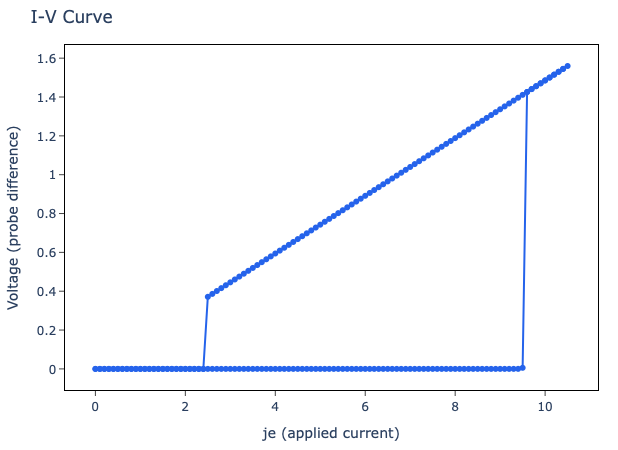

In [69]:
# Plot I-V curve
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=iv_je, y=iv_voltage, mode='lines+markers',
    line=dict(width=2, color='#2563eb'),
    marker=dict(size=6),
    name='I-V',
))
fig.update_layout(
    title='I-V Curve',
    xaxis_title='je (applied current)',
    yaxis_title='Voltage (probe difference)',
    margin=dict(l=60, r=20, t=45, b=50),
    height=450, width=600, plot_bgcolor='white',
    xaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
    yaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
)
fig.show()

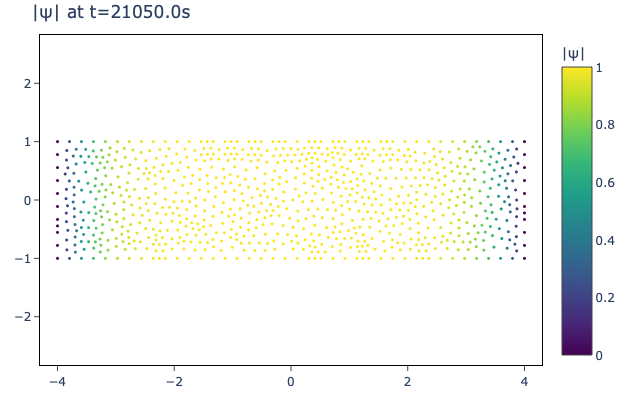

In [70]:
# Plot |psi| at the last saved frame
last_idx = len(sol_times) - 1
solution.load_tdgl_data(last_idx)
psi = solution.tdgl_data.psi
psi_abs = np.abs(psi)

fig = go.Figure(go.Scatter(
    x=points[:, 0], y=points[:, 1],
    mode='markers',
    marker=dict(
        size=3,
        color=psi_abs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title='|\u03C8|'),
    ),
    text=[f'|\u03C8|={v:.3f}' for v in psi_abs],
    hovertemplate='%{text}<extra></extra>',
))

xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()
m = 0.3
fig.update_layout(
    title=f'|\u03C8| at t={sol_times[last_idx]:.1f}s',
    xaxis=dict(range=[xmin - m, xmax + m], showline=True, linewidth=1,
               linecolor='black', mirror=True, ticks='outside'),
    yaxis=dict(scaleanchor='x', scaleratio=1, range=[ymin - m, ymax + m],
               showline=True, linewidth=1, linecolor='black', mirror=True, ticks='outside'),
    margin=dict(l=40, r=10, t=35, b=50),
    height=400, width=700, plot_bgcolor='white',
)
fig.show()

## Heatmap Animation

Interactive Plotly viewer with play/pause/seek controls.
One frame per timing step, computed on-demand from HDF5.
Works with completed simulation or live background solver (cell 22).


In [108]:
# Launch solver in background thread
import threading

if os.path.exists(output_path):
    os.remove(output_path)

options = tdgl.SolverOptions(
    solve_time=result['solve_time'],
    dt_init=dt_init,
    dt_max=dt_max,
    adaptive=adaptive,
    save_every=save_every,
    output_file=output_path,
)

sim_done = threading.Event()

def run_sim():
    global solution
    solution = tdgl.solve(
        device, options,
        terminal_currents=get_terminal_currents,
    )
    print(f'\nSimulation complete. {len(solution.times)} frames saved.')
    sim_done.set()

thread = threading.Thread(target=run_sim, daemon=True)
thread.start()
print('Solver running in background. Run the next cell to start the live viewer.')

Solver running in background. Run the next cell to start the live viewer.

In [17]:
import ipywidgets as widgets
import h5py
from scipy.interpolate import griddata

# Check sim_done event (set by cell 22 background solver)
try:
    _ = sim_done
except NameError:
    sim_done = threading.Event()
    sim_done.set()

# Interpolation grid
xmin, xmax = points[:, 0].min(), points[:, 0].max()
ymin, ymax = points[:, 1].min(), points[:, 1].max()
nx, ny = 100, 50
gx = np.linspace(xmin, xmax, nx)
gy = np.linspace(ymin, ymax, ny)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])

# Read frame times from HDF5
def read_frame_times():
    if not os.path.exists(output_path):
        return np.array([])
    try:
        with h5py.File(output_path, 'r') as f:
            if 'data' not in f:
                return np.array([])
            total = len(f['data'].keys())
            if total == 0:
                return np.array([])
            return np.array([
                float(f[f'data/{fi}'].attrs.get('time', 0))
                for fi in range(total)
            ])
    except Exception:
        return np.array([])

# Compute heatmap for a given step index
def compute_frame(step_idx):
    """Compute interpolated |psi| heatmap for timing step step_idx (0-based)."""
    s = steps[step_idx]
    frame_times = read_frame_times()
    if len(frame_times) == 0:
        return np.zeros((ny, nx)), {'je': s['je_end'], 'step': step_idx + 1, 'time': 0}

    mid_t = (s['save_start'] + s['save_end']) / 2
    mask = (frame_times >= s['save_start']) & (frame_times <= s['save_end'])
    step_fi = np.where(mask)[0]

    if len(step_fi) > 0:
        fi = step_fi[len(step_fi) // 2]
    else:
        fi = int(np.argmin(np.abs(frame_times - mid_t)))

    with h5py.File(output_path, 'r') as f:
        psi = np.abs(np.array(f[f'data/{fi}/psi']))

    Z = griddata(points, psi, grid_pts, method='cubic',
                 fill_value=0.0).reshape(ny, nx)
    Z = np.clip(Z, 0, None)
    info = {'je': s['je_end'], 'step': step_idx + 1,
            'time': (s['save_start'] + s['save_end']) / 2}
    return Z, info

n_steps = len(steps)

# Initial frame
initial_Z, initial_info = compute_frame(0)

# Electrode rectangles as shapes
electrode_shapes = []
for t in device.terminal_info():
    idx = t.site_indices
    x0, x1 = points[idx, 0].min(), points[idx, 0].max()
    y0, y1 = points[idx, 1].min(), points[idx, 1].max()
    electrode_shapes.append(dict(
        type='rect', x0=x0, x1=x1, y0=y0, y1=y1,
        line=dict(color='cyan', width=1.5, dash='dash'),
        fillcolor='rgba(0,0,0,0)', layer='above',
    ))

# Build Plotly FigureWidget
fig = go.FigureWidget(
    go.Heatmap(x=gx, y=gy, z=initial_Z,
               colorscale='Inferno', zmin=0, zmax=1.05,
               colorbar=dict(title='|ψ|'),
               showscale=True),
)
fig.update_layout(
    title=f'|ψ|  je={initial_info["je"]:.2f}  t={initial_info["time"]:.0f}s  '
          f'(step 1/{n_steps})',
    xaxis=dict(showline=True, linewidth=1, linecolor='black',
               mirror=True, ticks='outside'),
    yaxis=dict(scaleanchor='x', scaleratio=1, showline=True,
               linewidth=1, linecolor='black', mirror=True, ticks='outside'),
    margin=dict(l=50, r=10, t=35, b=50),
    height=400, width=700, plot_bgcolor='white',
    shapes=electrode_shapes,
)

# Play + Slider controls
slider = widgets.IntSlider(
    value=0, min=0, max=n_steps - 1, step=1,
    description='Step:', continuous_update=True,
)
play = widgets.Play(
    value=0, min=0, max=n_steps - 1, interval=80,
    description='Play',
)
widgets.jslink((play, 'value'), (slider, 'value'))

# Frame update callback
def on_slider_change(change):
    idx = change['new']
    Z, info = compute_frame(idx)
    fig.data[0].z = Z
    fig.update_layout(
        title=f'|ψ|  je={info["je"]:.2f}  t={info["time"]:.0f}s  '
              f'(step {info["step"]}/{n_steps})')

slider.observe(on_slider_change, names='value')

# Poller: update slider max during live simulation
def poll_progress():
    if sim_done.is_set():
        return
    frame_times = read_frame_times()
    if len(frame_times) > 0:
        completed = 0
        for s in steps:
            if np.any((frame_times >= s['save_start']) & (frame_times <= s['save_end'])):
                completed += 1
            else:
                break
        if completed > 0:
            slider.max = completed - 1
            play.max = completed - 1
    threading.Timer(2.0, poll_progress).start()

if not sim_done.is_set():
    poll_progress()

# Display
controls = widgets.HBox([play, slider])
display(widgets.VBox([controls, fig]))
print(f'{n_steps} timing steps — use Play/Slider to browse frames')


211 frames (211 with data) — je 0.00 → 10.50 → 0.00

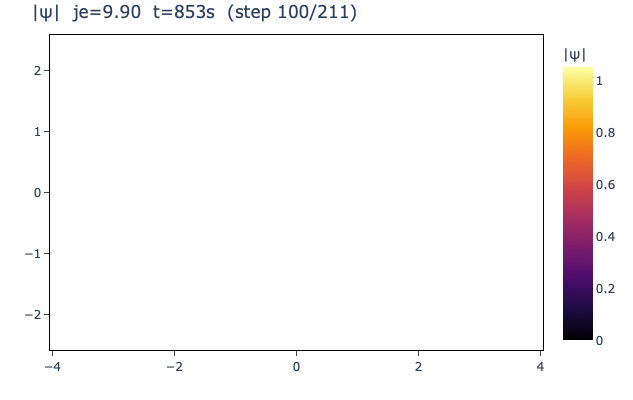

In [103]:
# View a single frame by timing step index (1-based)
step_idx = 100  # change this (1..211)

if step_idx < 1 or step_idx > len(steps):
    print(f'Step must be 1..{len(steps)}')
else:
    Z, info = compute_frame(step_idx - 1)
    fig_single = go.Figure(go.Heatmap(
        x=gx, y=gy, z=Z, colorscale='Inferno',
        zmin=0, zmax=1.05, showscale=True,
        colorbar=dict(title='|ψ|'),
    ))
    fig_single.update_layout(
        title=f'|ψ|  je={info["je"]:.2f}  t={info["time"]:.0f}s  '
              f'(step {info["step"]}/{len(steps)})',
        xaxis=dict(showline=True, linewidth=1, linecolor='black',
                   mirror=True, ticks='outside'),
        yaxis=dict(scaleanchor='x', scaleratio=1, showline=True,
                   linewidth=1, linecolor='black', mirror=True, ticks='outside'),
        margin=dict(l=50, r=10, t=35, b=50),
        height=400, width=700, plot_bgcolor='white',
        shapes=electrode_shapes,
    )
    fig_single.show()


## MinIO Artifact Management

In [ ]:
# Delete current run's artifact
minio.delete_object(Bucket='argo-artifacts', Key=device_key)
print(f'Deleted {device_key}')

In [ ]:
# List all artifacts
resp = minio.list_objects_v2(Bucket='argo-artifacts')
items = resp.get('Contents', [])

if not items:
    print('No artifacts in bucket.')
else:
    print(f'Found {len(items)} artifact(s):\n')
    for obj in items:
        print(f'  {obj["Key"]}  ({obj["Size"]/1024:.1f} KB)')

In [ ]:
# Delete a specific artifact — change the key below
delete_key = '<run-id>/device.pkl'

minio.delete_object(Bucket='argo-artifacts', Key=delete_key)
print(f'Deleted {delete_key}')

In [ ]:
# Delete ALL device artifacts
resp = minio.list_objects_v2(Bucket='argo-artifacts')
count = 0
for obj in resp.get('Contents', []):
    if 'device.pkl' in obj['Key']:
        minio.delete_object(Bucket='argo-artifacts', Key=obj['Key'])
        print(f'Deleted {obj["Key"]}')
        count += 1
print(f'\nDone. Removed {count} artifact(s).')